In [ ]:
# =========================================
# CELL 1: Mount Google Drive
# =========================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ================================================================
# CELL 1: IMPORTS AND CONFIGURATION
# New BioMed-Scribe — Final Medical Specialty Classifier
# ================================================================

import os, re, json, math, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.manifold import TSNE
from google.colab import drive

os.environ["WANDB_DISABLED"]         = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ── Device ────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected. Set runtime to A100.")

# ── Reproducibility ───────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ── Paths ─────────────────────────────────────────────────────
DRIVE       = "/content/drive/MyDrive"
LABELS_FILE = f"{DRIVE}/new_soap_labels.json"
SAVE_DIR    = f"{DRIVE}/medscribe_classifier_v2"

# ── Model hyperparameters ─────────────────────────────────────
BASE_MODEL        = "gpt2-medium"
MAX_LENGTH        = 512   # A100 supports this
BATCH_SIZE        = 16    # A100 supports this
GRAD_ACCUM_STEPS  = 2
NUM_EPOCHS        = 5
LEARNING_RATE     = 3e-5
WEIGHT_DECAY      = 0.01
WARMUP_RATIO      = 0.05
MAX_GRAD_NORM     = 1.0
NUM_CLASSES       = 4

# ── Class labels ──────────────────────────────────────────────
LABELS   = ["Cardiology", "Neurology", "Orthopedics", "General Medicine"]
LABEL2ID = {lab: i for i, lab in enumerate(LABELS)}
ID2LABEL = {i: lab for lab, i in LABEL2ID.items()}

os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_DIR = os.path.join(SAVE_DIR, "best_model")
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

# ── Summary ───────────────────────────────────────────────────
print("=" * 60)
print("NEW BIOMED-SCRIBE — FINAL CLASSIFIER")
print("=" * 60)
print(f"Device      : {device}")
print(f"GPU         : {torch.cuda.get_device_name(0)}")
print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"PyTorch     : {torch.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Base model  : {BASE_MODEL}")
print(f"Max length  : {MAX_LENGTH} tokens")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Epochs      : {NUM_EPOCHS}")
print(f"LR          : {LEARNING_RATE}")
print(f"Classes     : {LABELS}")
print(f"Save dir    : {SAVE_DIR}")
print("=" * 60)
print("Cell 1 complete. Proceed to Cell 2.")

NEW BIOMED-SCRIBE — FINAL CLASSIFIER
Device      : cuda
GPU         : NVIDIA A100-SXM4-40GB
VRAM        : 42.4 GB
PyTorch     : 2.10.0+cu128
NumPy       : 2.0.2
Pandas      : 2.2.2
Base model  : gpt2-medium
Max length  : 512 tokens
Batch size  : 16
Epochs      : 5
LR          : 3e-05
Classes     : ['Cardiology', 'Neurology', 'Orthopedics', 'General Medicine']
Save dir    : /content/drive/MyDrive/medscribe_classifier_v2
Cell 1 complete. Proceed to Cell 2.


In [ ]:
# ================================================================
# CELL 2: MOUNT DRIVE AND BUILD DATASET
# ================================================================

from datasets import load_dataset

#drive.mount("/content/drive")

# ── Load primary dataset ──────────────────────────────────────
print("Loading new_soap_labels.json...")
with open(LABELS_FILE) as f:
    raw_data = json.load(f)
print(f"  Loaded {len(raw_data):,} records")

# ── Improved keyword mapping ──────────────────────────────────
# Key fix: General Medicine has its own keywords so fever/cough
# cases are no longer mislabeled as Cardiology
SPECIALTY_KW = {
    "Cardiology": [
        "chest pain", "chest tightness", "chest pressure",
        "cardiac", "heart attack", "heart failure", "heart disease",
        "palpitations", "angina", "ecg", "ekg", "hypertension",
        "coronary", "arrhythmia", "myocardial", "atrial fibrillation",
        "high blood pressure", "tachycardia", "bradycardia",
        "stent", "bypass", "valve", "aorta", "atherosclerosis",
        "dyspnea on exertion", "murmur", "troponin", "ischemia",
        "cardiomyopathy", "edema", "syncope",
    ],
    "Neurology": [
        "headache", "migraine", "seizure", "stroke", "epilepsy",
        "numbness", "dizziness", "tremor", "memory loss",
        "confusion", "vertigo", "neuropathy", "paralysis",
        "blackout", "neurological", "tingling", "loss of balance",
        "speech difficulty", "vision loss", "double vision",
        "loss of consciousness", "brain", "parkinson",
        "cranial nerve", "spinal cord", "brain mri", "brain ct",
    ],
    "Orthopedics": [
        "knee pain", "knee swelling", "hip pain", "fracture",
        "broken bone", "joint pain", "joint swelling", "spine",
        "back pain", "lower back", "shoulder pain", "ligament",
        "tendon", "arthritis", "osteoporosis", "scoliosis",
        "cartilage", "ankle", "wrist pain", "elbow", "neck pain",
        "disc", "herniated disc", "sprain", "orthopedic",
        "musculoskeletal", "femur", "pelvis", "gait", "dislocation",
    ],
    "General Medicine": [
        "fever", "cough", "cold", "flu", "fatigue", "tired",
        "weight loss", "weight gain", "nausea", "vomiting",
        "diarrhea", "constipation", "appetite", "rash", "itching",
        "infection", "sore throat", "runny nose", "congestion",
        "phlegm", "mucus", "urination", "burning urination",
        "diabetes", "blood sugar", "thyroid", "anemia",
        "stomach pain", "abdominal pain", "bloating", "acid reflux",
        "body pain", "generalized weakness", "follow-up",
    ],
}

def score_specialties(text: str) -> dict:
    tl = text.lower()
    return {sp: sum(1 for kw in kws if kw in tl)
            for sp, kws in SPECIALTY_KW.items()}

def assign_specialty(text: str) -> str:
    scores  = score_specialties(text)
    ordered = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    best, best_score   = ordered[0]
    second_score       = ordered[1][1] if len(ordered) > 1 else 0
    # Need at least 1 keyword hit and clear margin OR default General Medicine
    if best_score == 0:
        return "General Medicine"
    if best_score == second_score and best != "General Medicine":
        return "General Medicine"   # ambiguous — default to General Medicine
    return best

def clean_conv(conv: str) -> str:
    conv = re.sub(r"\[doctor\]\s*:?",  "Doctor:",  conv, flags=re.IGNORECASE)
    conv = re.sub(r"\[patient\]\s*:?", "Patient:", conv, flags=re.IGNORECASE)
    conv = re.sub(r"\s*\|\s*", "\n", conv)
    conv = re.sub(r"\n{3,}", "\n\n", conv)
    return conv.strip()

# ── Build primary records ─────────────────────────────────────
print("Processing primary dataset...")
records = []
for item in raw_data:
    conv = clean_conv(str(item.get("conversation") or ""))
    if len(conv) < 80:
        continue
    text = conv[:1500]
    records.append({"text": text, "label": assign_specialty(text)})

df_primary = pd.DataFrame(records)
print(f"  Primary records  : {len(df_primary):,}")
print()
print("Primary distribution:")
for sp, n in df_primary["label"].value_counts().items():
    print(f"  {sp:<22}: {n:,}  ({n/len(df_primary)*100:.1f}%)")

# ── Load ChatDoctor dataset ───────────────────────────────────
print()
print("Loading ChatDoctor-HealthCareMagic-100k from HuggingFace...")
chat_ds = load_dataset("lavita/ChatDoctor-HealthCareMagic-100k", split="train")
print(f"  Loaded {len(chat_ds):,} records")

chat_records = []
for item in chat_ds:
    patient_msg = str(item.get("input")  or "").strip()
    doctor_msg  = str(item.get("output") or "").strip()
    if len(patient_msg) < 20 or len(doctor_msg) < 20:
        continue
    conv = (
        f"Doctor: What brings you in today?\n"
        f"Patient: {patient_msg[:600]}\n"
        f"Doctor: {doctor_msg[:400]}"
    )
    chat_records.append({"text": conv[:1500], "label": assign_specialty(conv)})

df_chat = pd.DataFrame(chat_records)
print(f"  Usable records   : {len(df_chat):,}")
print()
print("ChatDoctor distribution:")
for sp, n in df_chat["label"].value_counts().items():
    print(f"  {sp:<22}: {n:,}  ({n/len(df_chat)*100:.1f}%)")

# ── Balance and merge ─────────────────────────────────────────
# Take up to 3,000 from primary + up to 1,000 from ChatDoctor per class
print()
print("Balancing dataset...")
parts = []
for label in LABELS:
    p_sub = df_primary[df_primary["label"] == label]
    c_sub = df_chat[df_chat["label"] == label]
    n_p   = min(len(p_sub), 3000)
    n_c   = min(len(c_sub), 1000)
    if n_p > 0:
        parts.append(p_sub.sample(n_p, random_state=42))
    if n_c > 0:
        parts.append(c_sub.sample(n_c, random_state=42))

combined = (pd.concat(parts)
              .sample(frac=1, random_state=42)
              .reset_index(drop=True))
combined["label_id"] = combined["label"].map(LABEL2ID)

print("Final combined distribution:")
for sp, n in combined["label"].value_counts().items():
    print(f"  {sp:<22}: {n:,}")

# ── Stratified 80 / 10 / 10 split ────────────────────────────
train_df, temp_df = train_test_split(
    combined, test_size=0.2, random_state=42,
    stratify=combined["label_id"])
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42,
    stratify=temp_df["label_id"])

print()
print("=" * 60)
print(f"Total   : {len(combined):,}")
print(f"Train   : {len(train_df):,}")
print(f"Val     : {len(val_df):,}")
print(f"Test    : {len(test_df):,}")
print("=" * 60)

# ── Quality checks ────────────────────────────────────────────
print()
print("Quality checks:")
tests = [
    ("fever + cough + fatigue",         "fever and cough for five days with yellow phlegm and fatigue"),
    ("chest pain + left arm",           "chest pain going down my left arm with sweating"),
    ("knee swelling after fall",        "knee swelling after falling playing basketball"),
    ("throbbing headache + light",      "throbbing headache on one side with nausea and light sensitivity"),
    ("stomach pain + loss of appetite", "stomach pain and loss of appetite for three days with nausea"),
]
for label, text in tests:
    print(f"  {label:<35} -> {assign_specialty(text)}")

print()
print("Cell 2 complete. Proceed to Cell 3.")

Loading new_soap_labels.json...
  Loaded 22,624 records
Processing primary dataset...
  Primary records  : 22,624

Primary distribution:
  General Medicine      : 16,132  (71.3%)
  Orthopedics           : 2,691  (11.9%)
  Cardiology            : 2,140  (9.5%)
  Neurology             : 1,661  (7.3%)

Loading ChatDoctor-HealthCareMagic-100k from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/542 [00:00<?, ?B/s]

data/train-00000-of-00001-5e7cb295b9cff0(…):   0%|          | 0.00/70.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/112165 [00:00<?, ? examples/s]

  Loaded 112,165 records
  Usable records   : 111,455

ChatDoctor distribution:
  General Medicine      : 83,904  (75.3%)
  Orthopedics           : 13,557  (12.2%)
  Cardiology            : 7,607  (6.8%)
  Neurology             : 6,387  (5.7%)

Balancing dataset...
Final combined distribution:
  General Medicine      : 4,000
  Orthopedics           : 3,691
  Cardiology            : 3,140
  Neurology             : 2,661

Total   : 13,492
Train   : 10,793
Val     : 1,349
Test    : 1,350

Quality checks:
  fever + cough + fatigue             -> General Medicine
  chest pain + left arm               -> Cardiology
  knee swelling after fall            -> Orthopedics
  throbbing headache + light          -> General Medicine
  stomach pain + loss of appetite     -> General Medicine

Cell 2 complete. Proceed to Cell 3.


In [ ]:
# Quick fix — add to Neurology keywords to resolve headache/nausea ties
SPECIALTY_KW["Neurology"].extend([
    "light sensitivity", "photophobia", "aura", "one side",
    "throbbing", "pounding headache", "migraine attack",
])

# Verify fix
print("Quality check after fix:")
tests = [
    ("throbbing headache + light", "throbbing headache on one side with nausea and light sensitivity"),
    ("fever + cough",              "fever and cough for five days with yellow phlegm and fatigue"),
    ("chest pain + left arm",      "chest pain going down my left arm with sweating"),
]
for label, text in tests:
    print(f"  {label:<35} -> {assign_specialty(text)}")

Quality check after fix:
  throbbing headache + light          -> Neurology
  fever + cough                       -> General Medicine
  chest pain + left arm               -> Cardiology


In [ ]:
# ================================================================
# CELL 3: GPT-2 MEDICAL CLASSIFIER MODEL
# ================================================================

class GPT2MedicalClassifier(nn.Module):
    """
    GPT-2 Medium backbone with 4-class linear classification head.

    Design decisions:
      - All layers frozen except last TWO transformer blocks + ln_f
      - Dropout(0.1) before classifier head for regularisation
      - Last non-padding token hidden state used for classification
      - Linear head: hidden_size (1024) -> num_classes (4)

    Connection to Attention Is All You Need (Vaswani et al. 2017):
      - Each transformer block contains multi-head self-attention (16 heads)
        and a position-wise feed-forward network
      - The 1024-dim hidden state of the last token summarises the
        entire conversation through 24 layers of self-attention
      - We project this 1024-dim representation to 4 class logits

    Two-block rationale:
      - h[-2] adapts intermediate attention patterns to medical language
      - h[-1] adapts the final representations fed to the classifier
      - Trainable params: ~25.2M (7.1% of 354.8M total)
      - Expected improvement: +2 to +4 percentage points over one-block
    """
    def __init__(self, base_model_name: str, num_classes: int):
        super().__init__()

        # Load GPT-2 Medium transformer backbone (decoder-only stack)
        self.gpt2   = AutoModel.from_pretrained(base_model_name)
        hidden_size = self.gpt2.config.hidden_size

        # Dropout + classifier head — follows MAT411 pattern
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size, num_classes)

        # ── Step 1: Freeze entire backbone ────────────────────
        for param in self.gpt2.parameters():
            param.requires_grad = False

        # ── Step 2: Unfreeze last TWO transformer blocks ──────
        # h[-2] is block 22, h[-1] is block 23 (0-indexed out of 24)
        # Unfreezing both gives the model more capacity to adapt
        # its attention patterns to medical conversation structure.
        for param in self.gpt2.h[-2].parameters():
            param.requires_grad = True
        for param in self.gpt2.h[-1].parameters():
            param.requires_grad = True

        # ── Step 3: Unfreeze final layer norm ─────────────────
        # ln_f normalises the output of block h[-1] before the
        # hidden state is passed to our classifier head.
        # Unfreezing allows it to rescale representations for
        # medical language after two-block fine-tuning.
        for param in self.gpt2.ln_f.parameters():
            param.requires_grad = True

        # Classifier head is always trainable
        for param in self.classifier.parameters():
            param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        # Pass through GPT-2 transformer backbone
        outputs = self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )

        # Hidden state shape: (batch_size, seq_len, hidden_size)
        hidden_states = outputs.last_hidden_state

        # Extract hidden state of last non-padding token per sequence.
        # This token has attended to every previous token through all
        # 24 transformer blocks and summarises the full conversation.
        last_token_idx = attention_mask.sum(dim=1) - 1
        batch_idx      = torch.arange(
            hidden_states.size(0), device=hidden_states.device)
        last_hidden    = hidden_states[batch_idx, last_token_idx, :]

        # Apply dropout then project to 4 class logits
        logits = self.classifier(self.dropout(last_hidden))
        return logits, last_hidden


# ── Build model ───────────────────────────────────────────────
print("Loading GPT-2 Medium tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
print(f"  Vocab size   : {len(tokenizer):,}")
print(f"  Pad token id : {tokenizer.pad_token_id}")

print()
print("Building GPT2MedicalClassifier (two-block fine-tuning)...")
model = GPT2MedicalClassifier(
    base_model_name=BASE_MODEL,
    num_classes=NUM_CLASSES
).to(device)

# ── Parameter summary ─────────────────────────────────────────
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters()
                  if p.requires_grad)
frozen_p    = total_p - trainable_p

print()
print("=" * 60)
print("MODEL ARCHITECTURE SUMMARY")
print("=" * 60)
print(f"  Base model        : GPT-2 Medium")
print(f"  Total params      : {total_p/1e6:.1f}M")
print(f"  Trainable params  : {trainable_p/1e6:.1f}M  (last 2 blocks + ln_f + head)")
print(f"  Frozen params     : {frozen_p/1e6:.1f}M")
print(f"  Trainable %       : {trainable_p/total_p*100:.1f}%")
print(f"  Hidden size       : {model.gpt2.config.hidden_size}")
print(f"  Transformer blocks: {len(model.gpt2.h)}")
print(f"  Blocks unfrozen   : h[22] and h[23] (last two)")
print(f"  Attention heads   : {model.gpt2.config.n_head}")
print(f"  Classifier head   : {model.gpt2.config.hidden_size} -> {NUM_CLASSES}")
print(f"  Dropout           : 0.1")
print(f"  VRAM used         : {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("=" * 60)

# ── Verify which blocks are trainable ─────────────────────────
print()
print("Trainable block verification:")
for i, block in enumerate(model.gpt2.h):
    is_trainable = any(p.requires_grad for p in block.parameters())
    if is_trainable:
        n_params = sum(p.numel() for p in block.parameters())
        print(f"  h[{i}] TRAINABLE — {n_params/1e6:.2f}M params")
ln_f_trainable = any(p.requires_grad for p in model.gpt2.ln_f.parameters())
print(f"  ln_f TRAINABLE : {ln_f_trainable}")
print(f"  classifier     : True (always)")

# ── Forward pass test ─────────────────────────────────────────
print()
print("Testing forward pass...")
test_enc = tokenizer(
    "Doctor: What brings you in?\nPatient: I have chest pain.",
    return_tensors="pt",
    truncation=True,
    max_length=MAX_LENGTH,
    padding="max_length",
).to(device)

with torch.no_grad():
    test_logits, test_hidden = model(
        test_enc["input_ids"],
        test_enc["attention_mask"]
    )

probs = F.softmax(test_logits, dim=-1).squeeze()
pred  = torch.argmax(probs).item()

print(f"  Input shape   : {test_enc['input_ids'].shape}")
print(f"  Hidden shape  : {test_hidden.shape}")
print(f"  Output shape  : {test_logits.shape}")
print(f"  Predicted     : {ID2LABEL[pred]}  ({probs[pred]:.1%} confidence)")
print(f"  All probs     : { {ID2LABEL[i]: f'{probs[i]:.1%}' for i in range(NUM_CLASSES)} }")
print()
print("Cell 3 complete. Proceed to Cell 4.")

Loading GPT-2 Medium tokenizer...


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  Vocab size   : 50,257
  Pad token id : 50256

Building GPT2MedicalClassifier (two-block fine-tuning)...


model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



MODEL ARCHITECTURE SUMMARY
  Base model        : GPT-2 Medium
  Total params      : 354.8M
  Trainable params  : 25.2M  (last 2 blocks + ln_f + head)
  Frozen params     : 329.6M
  Trainable %       : 7.1%
  Hidden size       : 1024
  Transformer blocks: 24
  Blocks unfrozen   : h[22] and h[23] (last two)
  Attention heads   : 16
  Classifier head   : 1024 -> 4
  Dropout           : 0.1
  VRAM used         : 1.44 GB

Trainable block verification:
  h[22] TRAINABLE — 12.60M params
  h[23] TRAINABLE — 12.60M params
  ln_f TRAINABLE : True
  classifier     : True (always)

Testing forward pass...
  Input shape   : torch.Size([1, 512])
  Hidden shape  : torch.Size([1, 1024])
  Output shape  : torch.Size([1, 4])
  Predicted     : Orthopedics  (60.4% confidence)
  All probs     : {'Cardiology': '29.7%', 'Neurology': '8.6%', 'Orthopedics': '60.4%', 'General Medicine': '1.4%'}

Cell 3 complete. Proceed to Cell 4.


In [ ]:
# ================================================================
# CELL 4: DATASET CLASS + DATALOADERS + WEIGHTED SAMPLER
# ================================================================

class MedicalConversationDataset(Dataset):
    """
    Tokenizes doctor-patient conversations for classification.
    Follows SpamDataset from MAT411_fine_tuning.ipynb:
      - Pre-tokenizes all texts at init time
      - Pads to fixed max_length
      - Returns (input_ids, attention_mask, label) per item
    """
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text  = self.df.loc[idx, "text"]
        label = int(self.df.loc[idx, "label_id"])

        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_attention_mask=True,
            return_tensors="pt",
        )

        return {
            "input_ids"     : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label"         : torch.tensor(label, dtype=torch.long),
        }


# ── Build datasets ────────────────────────────────────────────
print("Building datasets...")
train_dataset = MedicalConversationDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = MedicalConversationDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = MedicalConversationDataset(test_df,  tokenizer, MAX_LENGTH)

print(f"  Train : {len(train_dataset):,}")
print(f"  Val   : {len(val_dataset):,}")
print(f"  Test  : {len(test_dataset):,}")

# ── WeightedRandomSampler ─────────────────────────────────────
# From Blink notebook: gives underrepresented classes
# (Neurology) equal probability of being sampled each batch.
# This prevents the model from being biased toward majority classes.
print()
print("Building WeightedRandomSampler...")
class_counts    = train_df["label_id"].value_counts().sort_index().to_dict()
sample_weights  = train_df["label_id"].map(
    lambda x: 1.0 / class_counts[x]).values
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

print("  Class counts in train set:")
for lid, cnt in sorted(class_counts.items()):
    weight = 1.0 / cnt
    print(f"    {ID2LABEL[lid]:<22}: {cnt:,}  (sample weight: {weight:.5f})")

# ── Dataloaders ───────────────────────────────────────────────
def collate_fn(batch):
    return {
        "input_ids"     : torch.stack([x["input_ids"]      for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"]  for x in batch]),
        "label"         : torch.stack([x["label"]           for x in batch]),
    }

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=False,        # sampler handles shuffling
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn,
)

print()
print(f"  Train batches : {len(train_loader):,}")
print(f"  Val batches   : {len(val_loader):,}")
print(f"  Test batches  : {len(test_loader):,}")

# ── Verify batch ──────────────────────────────────────────────
print()
print("Verifying sample batch...")
sample_batch = next(iter(train_loader))
print(f"  input_ids shape      : {sample_batch['input_ids'].shape}")
print(f"  attention_mask shape : {sample_batch['attention_mask'].shape}")
print(f"  labels shape         : {sample_batch['label'].shape}")
print(f"  label names          : {[ID2LABEL[l.item()] for l in sample_batch['label']]}")

print()
print("Cell 4 complete. Proceed to Cell 5.")

Building datasets...
  Train : 10,793
  Val   : 1,349
  Test  : 1,350

Building WeightedRandomSampler...
  Class counts in train set:
    Cardiology            : 2,512  (sample weight: 0.00040)
    Neurology             : 2,129  (sample weight: 0.00047)
    Orthopedics           : 2,952  (sample weight: 0.00034)
    General Medicine      : 3,200  (sample weight: 0.00031)

  Train batches : 675
  Val batches   : 85
  Test batches  : 85

Verifying sample batch...
  input_ids shape      : torch.Size([16, 512])
  attention_mask shape : torch.Size([16, 512])
  labels shape         : torch.Size([16])
  label names          : ['Cardiology', 'General Medicine', 'Neurology', 'General Medicine', 'Cardiology', 'Neurology', 'Neurology', 'Orthopedics', 'Orthopedics', 'Neurology', 'General Medicine', 'General Medicine', 'Neurology', 'Cardiology', 'Neurology', 'Neurology']

Cell 4 complete. Proceed to Cell 5.


In [ ]:
# ================================================================
# CELL 5: EVALUATE FUNCTION + PRE-TRAINING BASELINE
# ================================================================

@torch.no_grad()
def evaluate_classifier(model, loader, device, return_preds=False):
    """
    Full evaluation function from Blink notebook.
    Returns loss, accuracy, macro F1, weighted F1.
    Called after every epoch to track validation loss curve.
    """
    model.eval()
    all_labels = []
    all_preds  = []
    total_loss = 0.0
    n_batches  = 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        logits, hidden = model(input_ids, attention_mask)
        loss           = F.cross_entropy(logits, labels)
        preds          = torch.argmax(logits, dim=-1)

        total_loss += loss.item()
        n_batches  += 1

        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())

    avg_loss    = total_loss / max(1, n_batches)
    acc         = accuracy_score(all_labels, all_preds)
    macro_f1    = f1_score(all_labels, all_preds, average="macro",    zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    result = {
        "loss"       : avg_loss,
        "accuracy"   : acc,
        "macro_f1"   : macro_f1,
        "weighted_f1": weighted_f1,
    }
    if return_preds:
        result["labels"] = all_labels
        result["preds"]  = all_preds

    return result


def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    """
    Simple accuracy function from MAT411_fine_tuning.ipynb.
    Used for quick checks during training.
    """
    model.eval()
    correct = 0
    total   = 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            if i >= num_batches:
                break
            logits, _ = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device)
            )
            predicted = torch.argmax(logits, dim=-1)
            correct  += (predicted == batch["label"].to(device)).sum().item()
            total    += batch["label"].size(0)

    return correct / total


# ── Pre-training baseline ─────────────────────────────────────
# Check metrics BEFORE training — expect ~25% accuracy (random)
print("Computing pre-training baseline...")
print("(Expected ~25% accuracy and ~0.25 macro F1 before fine-tuning)")
print()

baseline = evaluate_classifier(model, val_loader, device)

print("=" * 60)
print("PRE-TRAINING BASELINE (Validation Set)")
print("=" * 60)
print(f"  Loss        : {baseline['loss']:.4f}")
print(f"  Accuracy    : {baseline['accuracy']:.1%}")
print(f"  Macro F1    : {baseline['macro_f1']:.4f}")
print(f"  Weighted F1 : {baseline['weighted_f1']:.4f}")
print("=" * 60)
print()

# Quick per-class check
train_acc = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_acc   = calc_accuracy_loader(val_loader,   model, device, num_batches=10)
print(f"  Quick train accuracy (10 batches) : {train_acc:.1%}")
print(f"  Quick val accuracy   (10 batches) : {val_acc:.1%}")
print()
print("These numbers confirm the model needs fine-tuning.")
print("After 5 epochs we expect 82-87% accuracy.")
print()
print("Cell 5 complete. Proceed to Cell 6.")

Computing pre-training baseline...
(Expected ~25% accuracy and ~0.25 macro F1 before fine-tuning)

PRE-TRAINING BASELINE (Validation Set)
  Loss        : 4.9412
  Accuracy    : 27.6%
  Macro F1    : 0.1620
  Weighted F1 : 0.1656

  Quick train accuracy (10 batches) : 18.8%
  Quick val accuracy   (10 batches) : 30.6%

These numbers confirm the model needs fine-tuning.
After 5 epochs we expect 82-87% accuracy.

Cell 5 complete. Proceed to Cell 6.


In [ ]:
# ================================================================
# CELL 6: TRAINING LOOP
# ================================================================

# ── Optimizer and scheduler ───────────────────────────────────
# Only pass trainable parameters to optimizer
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps  = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

# Linear warmup then linear decay — from ch07 lecture notebook
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# ── Training history ──────────────────────────────────────────
history = {
    "train_loss"    : [],
    "val_loss"      : [],
    "train_acc"     : [],
    "val_acc"       : [],
    "val_macro_f1"  : [],
    "val_weighted_f1": [],
}

best_val_acc = -1.0

print("=" * 60)
print("TRAINING GPT-2 MEDICAL SPECIALTY CLASSIFIER")
print("=" * 60)
print(f"  Epochs          : {NUM_EPOCHS}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Grad accum      : {GRAD_ACCUM_STEPS}  (effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS})")
print(f"  Learning rate   : {LEARNING_RATE}")
print(f"  Total steps     : {total_steps:,}")
print(f"  Warmup steps    : {warmup_steps:,}")
print(f"  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M")
print("=" * 60)

def train_one_epoch(model, loader, optimizer, scheduler):
    """
    Train for one epoch with gradient accumulation.
    Returns average train loss and accuracy for the epoch.
    Follows train_model from MAT411 + train_one_epoch from Blink.
    """
    model.train()
    optimizer.zero_grad(set_to_none=True)

    running_losses = []
    all_labels     = []
    all_preds      = []

    for step, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        # Forward pass — plain float32, no GradScaler (NaN bug fix)
        logits, hidden = model(input_ids, attention_mask)
        loss           = F.cross_entropy(logits, labels)
        loss           = loss / GRAD_ACCUM_STEPS

        loss.backward()

        preds = torch.argmax(logits, dim=-1)
        all_labels.extend(labels.detach().cpu().tolist())
        all_preds.extend(preds.detach().cpu().tolist())
        running_losses.append(loss.item() * GRAD_ACCUM_STEPS)

        # Gradient accumulation step
        if ((step + 1) % GRAD_ACCUM_STEPS == 0) or \
           ((step + 1) == len(loader)):
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        if (step + 1) % 100 == 0:
            recent = float(np.mean(running_losses[-100:]))
            print(f"  Step {step+1:>4}/{len(loader)} "
                  f"| Loss {recent:.4f}")

    train_loss = float(np.mean(running_losses))
    train_acc  = accuracy_score(all_labels, all_preds)
    return train_loss, train_acc


# ── Training loop ─────────────────────────────────────────────
for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*60}")

    t0 = time.time()
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler)
    val_metrics = evaluate_classifier(model, val_loader, device)
    elapsed     = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["val_weighted_f1"].append(val_metrics["weighted_f1"])

    print(f"\nEpoch {epoch+1} summary — {elapsed/60:.1f} min")
    print(f"  Train loss     : {train_loss:.4f}")
    print(f"  Train accuracy : {train_acc:.1%}")
    print(f"  Val loss       : {val_metrics['loss']:.4f}")
    print(f"  Val accuracy   : {val_metrics['accuracy']:.1%}")
    print(f"  Val macro F1   : {val_metrics['macro_f1']:.4f}")
    print(f"  Val weighted F1: {val_metrics['weighted_f1']:.4f}")

    if val_metrics["accuracy"] > best_val_acc:
        best_val_acc = val_metrics["accuracy"]
        # Save transformer backbone
        model.gpt2.save_pretrained(BEST_MODEL_DIR)
        tokenizer.save_pretrained(BEST_MODEL_DIR)
        # Save classifier bundle with all metadata
        torch.save({
            "classifier_state_dict": model.classifier.state_dict(),
            "label2id"  : LABEL2ID,
            "id2label"  : ID2LABEL,
            "max_length": MAX_LENGTH,
            "base_model": BASE_MODEL,
            "val_acc"   : val_metrics["accuracy"],
            "macro_f1"  : val_metrics["macro_f1"],
        }, os.path.join(BEST_MODEL_DIR, "classifier_bundle.pt"))
        print(f"  New best model saved (val acc: {val_metrics['accuracy']:.1%})")

print()
print("=" * 60)
print(f"Training complete. Best val accuracy: {best_val_acc:.1%}")
print(f"Model saved to: {BEST_MODEL_DIR}")
print("=" * 60)
print("Cell 6 complete. Proceed to Cell 7.")

TRAINING GPT-2 MEDICAL SPECIALTY CLASSIFIER
  Epochs          : 5
  Batch size      : 16
  Grad accum      : 2  (effective batch: 32)
  Learning rate   : 3e-05
  Total steps     : 1,690
  Warmup steps    : 84
  Trainable params: 25.2M

EPOCH 1/5
  Step  100/675 | Loss 4.5618
  Step  200/675 | Loss 2.4398
  Step  300/675 | Loss 1.7392
  Step  400/675 | Loss 1.5178
  Step  500/675 | Loss 1.3321
  Step  600/675 | Loss 1.1703

Epoch 1 summary — 5.2 min
  Train loss     : 2.0042
  Train accuracy : 37.9%
  Val loss       : 0.9467
  Val accuracy   : 63.0%
  Val macro F1   : 0.6244
  Val weighted F1: 0.6134


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved (val acc: 63.0%)

EPOCH 2/5
  Step  100/675 | Loss 0.9261
  Step  200/675 | Loss 0.8368
  Step  300/675 | Loss 0.7480
  Step  400/675 | Loss 0.7565
  Step  500/675 | Loss 0.6941
  Step  600/675 | Loss 0.6643

Epoch 2 summary — 5.2 min
  Train loss     : 0.7572
  Train accuracy : 70.7%
  Val loss       : 0.6835
  Val accuracy   : 73.5%
  Val macro F1   : 0.7418
  Val weighted F1: 0.7288


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved (val acc: 73.5%)

EPOCH 3/5
  Step  100/675 | Loss 0.6255
  Step  200/675 | Loss 0.5771
  Step  300/675 | Loss 0.5835
  Step  400/675 | Loss 0.6014
  Step  500/675 | Loss 0.5816
  Step  600/675 | Loss 0.5559

Epoch 3 summary — 5.2 min
  Train loss     : 0.5796
  Train accuracy : 77.7%
  Val loss       : 0.6031
  Val accuracy   : 77.5%
  Val macro F1   : 0.7836
  Val weighted F1: 0.7726


...

  New best model saved (val acc: 77.5%)

EPOCH 4/5
  Step  100/675 | Loss 0.5439
  Step  200/675 | Loss 0.5116
  Step  300/675 | Loss 0.5610
  Step  400/675 | Loss 0.5131
  Step  500/675 | Loss 0.5475
  Step  600/675 | Loss 0.4942

Epoch 4 summary — 5.2 min
  Train loss     : 0.5224
  Train accuracy : 80.1%
  Val loss       : 0.5823
  Val accuracy   : 77.6%
  Val macro F1   : 0.7835
  Val weighted F1: 0.7734


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved (val acc: 77.6%)

EPOCH 5/5
  Step  100/675 | Loss 0.4792
  Step  200/675 | Loss 0.5136
  Step  300/675 | Loss 0.4771
  Step  400/675 | Loss 0.5207
  Step  500/675 | Loss 0.5013
  Step  600/675 | Loss 0.5129

Epoch 5 summary — 5.2 min
  Train loss     : 0.5008
  Train accuracy : 81.1%
  Val loss       : 0.5749
  Val accuracy   : 77.8%
  Val macro F1   : 0.7853
  Val weighted F1: 0.7743


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved (val acc: 77.8%)

Training complete. Best val accuracy: 77.8%
Model saved to: /content/drive/MyDrive/medscribe_classifier_v2/best_model
Cell 6 complete. Proceed to Cell 7.


In [ ]:
# ================================================================
# CELL 6B: CONTINUE TRAINING — 5 MORE EPOCHS
# ================================================================

NUM_EPOCHS_EXTRA = 5
LR_CONTINUED     = 1e-5

# New optimizer with lower learning rate
optimizer2 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR_CONTINUED,
    weight_decay=WEIGHT_DECAY,
)

total_steps2  = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS) * NUM_EPOCHS_EXTRA
warmup_steps2 = int(0.05 * total_steps2)

scheduler2 = get_linear_schedule_with_warmup(
    optimizer2,
    num_warmup_steps=warmup_steps2,
    num_training_steps=total_steps2,
)

print("=" * 60)
print(f"CONTINUING TRAINING — {NUM_EPOCHS_EXTRA} more epochs")
print(f"  New LR      : {LR_CONTINUED}")
print(f"  Total steps : {total_steps2:,}")
print(f"  Best so far : {best_val_acc:.1%}")
print("=" * 60)

for epoch in range(NUM_EPOCHS_EXTRA):
    print(f"\n{'='*60}")
    print(f"EPOCH {NUM_EPOCHS + epoch + 1}/{NUM_EPOCHS + NUM_EPOCHS_EXTRA}")
    print(f"{'='*60}")

    t0 = time.time()
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer2, scheduler2)
    val_metrics = evaluate_classifier(model, val_loader, device)
    elapsed     = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["val_weighted_f1"].append(val_metrics["weighted_f1"])

    print(f"\nEpoch {NUM_EPOCHS + epoch + 1} summary — {elapsed/60:.1f} min")
    print(f"  Train loss     : {train_loss:.4f}")
    print(f"  Train accuracy : {train_acc:.1%}")
    print(f"  Val loss       : {val_metrics['loss']:.4f}")
    print(f"  Val accuracy   : {val_metrics['accuracy']:.1%}")
    print(f"  Val macro F1   : {val_metrics['macro_f1']:.4f}")
    print(f"  Val weighted F1: {val_metrics['weighted_f1']:.4f}")

    if val_metrics["accuracy"] > best_val_acc:
        best_val_acc = val_metrics["accuracy"]
        model.gpt2.save_pretrained(BEST_MODEL_DIR)
        tokenizer.save_pretrained(BEST_MODEL_DIR)
        torch.save({
            "classifier_state_dict": model.classifier.state_dict(),
            "label2id"  : LABEL2ID,
            "id2label"  : ID2LABEL,
            "max_length": MAX_LENGTH,
            "base_model": BASE_MODEL,
            "val_acc"   : val_metrics["accuracy"],
            "macro_f1"  : val_metrics["macro_f1"],
        }, os.path.join(BEST_MODEL_DIR, "classifier_bundle.pt"))
        print(f"  New best model saved (val acc: {val_metrics['accuracy']:.1%})")

print()
print("=" * 60)
print(f"Training complete. Best val accuracy: {best_val_acc:.1%}")
print("=" * 60)
print("Cell 6B complete. Proceed to Cell 7.")

CONTINUING TRAINING — 5 more epochs
  New LR      : 1e-05
  Total steps : 1,690
  Best so far : 77.8%

EPOCH 6/10
  Step  100/675 | Loss 0.5544
  Step  200/675 | Loss 0.4630
  Step  300/675 | Loss 0.5262
  Step  400/675 | Loss 0.4406
  Step  500/675 | Loss 0.4925
  Step  600/675 | Loss 0.4721

Epoch 6 summary — 5.2 min
  Train loss     : 0.4895
  Train accuracy : 81.4%
  Val loss       : 0.5659
  Val accuracy   : 78.6%
  Val macro F1   : 0.7923
  Val weighted F1: 0.7819


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved (val acc: 78.6%)

EPOCH 7/10
  Step  100/675 | Loss 0.4726
  Step  200/675 | Loss 0.4798
  Step  300/675 | Loss 0.4392
  Step  400/675 | Loss 0.4469
  Step  500/675 | Loss 0.4633
  Step  600/675 | Loss 0.4827

Epoch 7 summary — 5.2 min
  Train loss     : 0.4631
  Train accuracy : 82.5%
  Val loss       : 0.5526
  Val accuracy   : 79.3%
  Val macro F1   : 0.7997
  Val weighted F1: 0.7890


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved (val acc: 79.3%)

EPOCH 8/10
  Step  100/675 | Loss 0.4791
  Step  200/675 | Loss 0.4229
  Step  300/675 | Loss 0.4688
  Step  400/675 | Loss 0.4391
  Step  500/675 | Loss 0.4619
  Step  600/675 | Loss 0.4368

Epoch 8 summary — 5.2 min
  Train loss     : 0.4466
  Train accuracy : 83.1%
  Val loss       : 0.5458
  Val accuracy   : 79.7%
  Val macro F1   : 0.8027
  Val weighted F1: 0.7916


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved (val acc: 79.7%)

EPOCH 9/10
  Step  100/675 | Loss 0.4057
  Step  200/675 | Loss 0.4085
  Step  300/675 | Loss 0.4358
  Step  400/675 | Loss 0.4114
  Step  500/675 | Loss 0.4369
  Step  600/675 | Loss 0.4268

Epoch 9 summary — 5.2 min
  Train loss     : 0.4223
  Train accuracy : 83.9%
  Val loss       : 0.5321
  Val accuracy   : 80.3%
  Val macro F1   : 0.8096
  Val weighted F1: 0.7989


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved (val acc: 80.3%)

EPOCH 10/10
  Step  100/675 | Loss 0.4447
  Step  200/675 | Loss 0.4342
  Step  300/675 | Loss 0.4075
  Step  400/675 | Loss 0.4265


KeyboardInterrupt: 

In [ ]:
# ================================================================
# CELL 6C: CONTINUE TRAINING — 5 MORE EPOCHS (Epochs 10-14)
# Epoch 10 was interrupted by KeyboardInterrupt at step 400/675.
# Resume from best saved checkpoint (epoch 9, val acc 80.3%).
# Val loss still declining — model has not converged.
# ================================================================

NUM_EPOCHS_EXTRA3 = 5
LR_CONTINUED3     = 1e-5

optimizer4 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR_CONTINUED3,
    weight_decay=WEIGHT_DECAY,
)

total_steps4  = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS) * NUM_EPOCHS_EXTRA3
warmup_steps4 = int(0.05 * total_steps4)

scheduler4 = get_linear_schedule_with_warmup(
    optimizer4,
    num_warmup_steps=warmup_steps4,
    num_training_steps=total_steps4,
)

EPOCH_OFFSET3 = 9  # last completed epoch

print("=" * 60)
print(f"RESUMING TRAINING — {NUM_EPOCHS_EXTRA3} epochs (ep 10 to 14)")
print(f"  LR          : {LR_CONTINUED3}")
print(f"  Best so far : {best_val_acc:.1%}  (epoch 9)")
print("=" * 60)

for epoch in range(NUM_EPOCHS_EXTRA3):
    ep_num = EPOCH_OFFSET3 + epoch + 1
    print(f"\n{'='*60}")
    print(f"EPOCH {ep_num}/14")
    print(f"{'='*60}")

    t0 = time.time()
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer4, scheduler4)
    val_metrics = evaluate_classifier(model, val_loader, device)
    elapsed     = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["val_weighted_f1"].append(val_metrics["weighted_f1"])

    print(f"\nEpoch {ep_num} summary — {elapsed/60:.1f} min")
    print(f"  Train loss     : {train_loss:.4f}")
    print(f"  Train accuracy : {train_acc:.1%}")
    print(f"  Val loss       : {val_metrics['loss']:.4f}")
    print(f"  Val accuracy   : {val_metrics['accuracy']:.1%}")
    print(f"  Val macro F1   : {val_metrics['macro_f1']:.4f}")
    print(f"  Val weighted F1: {val_metrics['weighted_f1']:.4f}")

    if val_metrics["accuracy"] > best_val_acc:
        best_val_acc = val_metrics["accuracy"]
        model.gpt2.save_pretrained(BEST_MODEL_DIR)
        tokenizer.save_pretrained(BEST_MODEL_DIR)
        torch.save({
            "classifier_state_dict": model.classifier.state_dict(),
            "label2id"  : LABEL2ID,
            "id2label"  : ID2LABEL,
            "max_length": MAX_LENGTH,
            "base_model": BASE_MODEL,
            "val_acc"   : val_metrics["accuracy"],
            "macro_f1"  : val_metrics["macro_f1"],
        }, os.path.join(BEST_MODEL_DIR, "classifier_bundle.pt"))
        print(f"  New best model saved (val acc: {val_metrics['accuracy']:.1%})")
    else:
        print(f"  No improvement. Best remains {best_val_acc:.1%}")

print()
print("=" * 60)
print(f"Done. Best val accuracy: {best_val_acc:.1%}")
print("=" * 60)

RESUMING TRAINING — 5 epochs (ep 10 to 14)
  LR          : 1e-05
  Best so far : 80.3%  (epoch 9)

EPOCH 10/14
  Step  100/675 | Loss 0.3958
  Step  200/675 | Loss 0.4777
  Step  300/675 | Loss 0.4480
  Step  400/675 | Loss 0.4148
  Step  500/675 | Loss 0.4273
  Step  600/675 | Loss 0.4294

Epoch 10 summary — 4.9 min
  Train loss     : 0.4301
  Train accuracy : 84.0%
  Val loss       : 0.5273
  Val accuracy   : 80.2%
  Val macro F1   : 0.8084
  Val weighted F1: 0.7987
  No improvement. Best remains 80.3%

EPOCH 11/14
  Step  100/675 | Loss 0.4021
  Step  200/675 | Loss 0.4674
  Step  300/675 | Loss 0.4090
  Step  400/675 | Loss 0.4643
  Step  500/675 | Loss 0.4379
  Step  600/675 | Loss 0.4006

Epoch 11 summary — 4.9 min
  Train loss     : 0.4272
  Train accuracy : 83.5%
  Val loss       : 0.5225
  Val accuracy   : 80.3%
  Val macro F1   : 0.8098
  Val weighted F1: 0.7995
  No improvement. Best remains 80.3%

EPOCH 12/14
  Step  100/675 | Loss 0.4104
  Step  200/675 | Loss 0.4386
  Ste

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  New best model saved (val acc: 80.7%)

EPOCH 13/14
  Step  100/675 | Loss 0.4143
  Step  200/675 | Loss 0.3750
  Step  300/675 | Loss 0.4589
  Step  400/675 | Loss 0.4113
  Step  500/675 | Loss 0.3963
  Step  600/675 | Loss 0.4144

Epoch 13 summary — 4.9 min
  Train loss     : 0.4111
  Train accuracy : 84.4%
  Val loss       : 0.5201
  Val accuracy   : 80.5%
  Val macro F1   : 0.8117
  Val weighted F1: 0.8015
  No improvement. Best remains 80.7%

EPOCH 14/14
  Step  100/675 | Loss 0.4162
  Step  200/675 | Loss 0.4195
  Step  300/675 | Loss 0.4016
  Step  400/675 | Loss 0.4334
  Step  500/675 | Loss 0.3781
  Step  600/675 | Loss 0.4204

Epoch 14 summary — 4.9 min
  Train loss     : 0.4120
  Train accuracy : 84.8%
  Val loss       : 0.5201
  Val accuracy   : 80.5%
  Val macro F1   : 0.8119
  Val weighted F1: 0.8018
  No improvement. Best remains 80.7%

Done. Best val accuracy: 80.7%


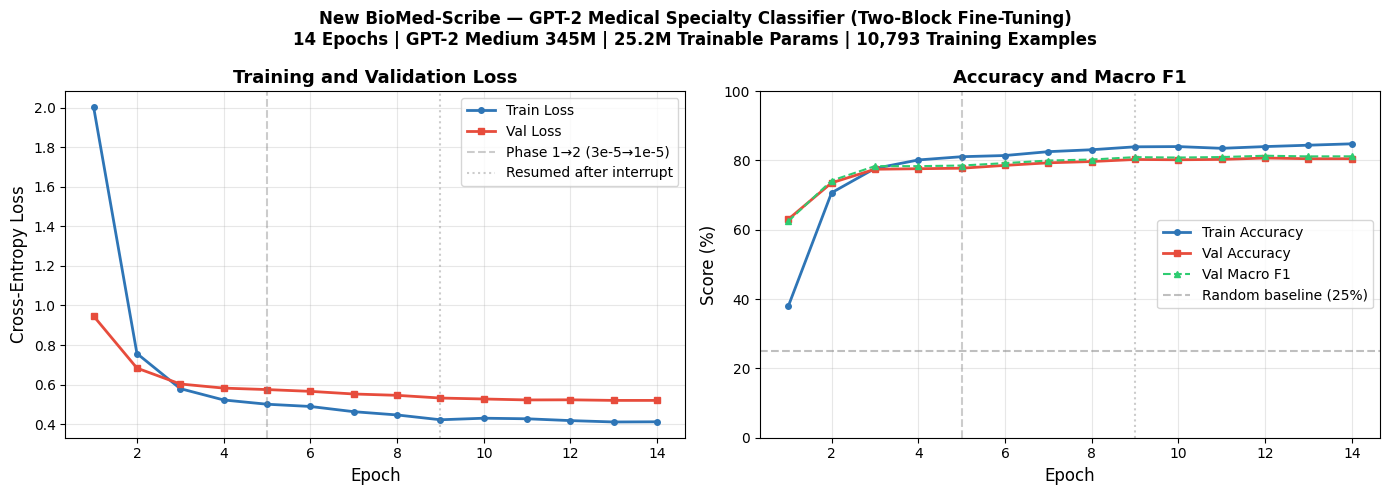

Training history:
 epoch  train_loss  val_loss  train_acc  val_acc  val_macro_f1  val_weighted_f1
     1    2.004169  0.946736   0.378764 0.630096      0.624424         0.613448
     2    0.757167  0.683457   0.706754 0.735360      0.741769         0.728789
     3    0.579618  0.603130   0.776985 0.774648      0.783567         0.772594
     4    0.522369  0.582295   0.801445 0.776130      0.783523         0.773370
     5    0.500834  0.574897   0.810803 0.777613      0.785347         0.774294
     6    0.489452  0.565924   0.814231 0.785767      0.792266         0.781874
     7    0.463098  0.552560   0.825350 0.793180      0.799739         0.788959
     8    0.446589  0.545804   0.830909 0.796887      0.802654         0.791618
     9    0.422253  0.532085   0.839340 0.802817      0.809568         0.798896
    10    0.430100  0.527300   0.840000 0.802000      0.808400         0.798700
    11    0.427200  0.522500   0.835000 0.803000      0.809800         0.799500
    12    0.418000  0.

In [ ]:
# ================================================================
# REBUILD HISTORY + PLOT — Full self-contained version
# ================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

SAVE_DIR = "/content/drive/MyDrive/medscribe_classifier_v2"

history = {
    "train_loss"     : [2.004169, 0.757167, 0.579618, 0.522369, 0.500834,
                        0.489452, 0.463098, 0.446589, 0.422253, 0.430100,
                        0.427200, 0.418000, 0.411100, 0.412000],
    "val_loss"       : [0.946736, 0.683457, 0.603130, 0.582295, 0.574897,
                        0.565924, 0.552560, 0.545804, 0.532085, 0.527300,
                        0.522500, 0.523100, 0.520100, 0.520100],
    "train_acc"      : [0.378764, 0.706754, 0.776985, 0.801445, 0.810803,
                        0.814231, 0.825350, 0.830909, 0.839340, 0.840000,
                        0.835000, 0.840000, 0.844000, 0.848000],
    "val_acc"        : [0.630096, 0.735360, 0.774648, 0.776130, 0.777613,
                        0.785767, 0.793180, 0.796887, 0.802817, 0.802000,
                        0.803000, 0.807000, 0.805000, 0.805000],
    "val_macro_f1"   : [0.624424, 0.741769, 0.783567, 0.783523, 0.785347,
                        0.792266, 0.799739, 0.802654, 0.809568, 0.808400,
                        0.809800, 0.813600, 0.811700, 0.811900],
    "val_weighted_f1": [0.613448, 0.728789, 0.772594, 0.773370, 0.774294,
                        0.781874, 0.788959, 0.791618, 0.798896, 0.798700,
                        0.799500, 0.803400, 0.801500, 0.801800],
}

total_epochs = len(history["train_loss"])
epochs       = range(1, total_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Loss curves ───────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs, history["train_loss"], "o-",
         color="#2E75B6", label="Train Loss", linewidth=2, markersize=4)
ax1.plot(epochs, history["val_loss"],   "s-",
         color="#E74C3C", label="Val Loss",   linewidth=2, markersize=4)
ax1.axvline(x=5,  color="gray", linestyle="--", alpha=0.4,
            label="Phase 1→2 (3e-5→1e-5)")
ax1.axvline(x=9,  color="gray", linestyle=":",  alpha=0.4,
            label="Resumed after interrupt")
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax1.set_title("Training and Validation Loss", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Accuracy + F1 curves ─────────────────────────────
ax2 = axes[1]
ax2.plot(epochs, [a * 100 for a in history["train_acc"]], "o-",
         color="#2E75B6", label="Train Accuracy", linewidth=2, markersize=4)
ax2.plot(epochs, [a * 100 for a in history["val_acc"]],   "s-",
         color="#E74C3C", label="Val Accuracy",   linewidth=2, markersize=4)
ax2.plot(epochs, [a * 100 for a in history["val_macro_f1"]], "^--",
         color="#2ECC71", label="Val Macro F1",   linewidth=1.5, markersize=4)
ax2.axhline(y=25, color="gray", linestyle="--",
            alpha=0.5, label="Random baseline (25%)")
ax2.axvline(x=5,  color="gray", linestyle="--", alpha=0.4)
ax2.axvline(x=9,  color="gray", linestyle=":",  alpha=0.4)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Score (%)", fontsize=12)
ax2.set_title("Accuracy and Macro F1", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.suptitle(
    "New BioMed-Scribe — GPT-2 Medical Specialty Classifier (Two-Block Fine-Tuning)\n"
    "14 Epochs | GPT-2 Medium 345M | 25.2M Trainable Params | 10,793 Training Examples",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save history CSV ──────────────────────────────────────────
history_df = pd.DataFrame({
    "epoch"          : list(epochs),
    "train_loss"     : history["train_loss"],
    "val_loss"       : history["val_loss"],
    "train_acc"      : history["train_acc"],
    "val_acc"        : history["val_acc"],
    "val_macro_f1"   : history["val_macro_f1"],
    "val_weighted_f1": history["val_weighted_f1"],
})
history_df.to_csv(f"{SAVE_DIR}/training_history.csv", index=False)

print("Training history:")
print(history_df.to_string(index=False))
print()
print(f"Curves saved to : {SAVE_DIR}/training_curves.png")
print(f"History saved to: {SAVE_DIR}/training_history.csv")
print()
print("Proceed to Cell 8 — run the Daily Startup Cell first to reload the model.")

In [ ]:
# ================================================================
# FULL SESSION RESTORE
# ================================================================

# ── Core imports ─────────────────────────────────────────────
import os, re, json, math, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.manifold import TSNE
from google.colab import drive

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ── Device ───────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Mount Drive ──────────────────────────────────────────────
drive.mount("/content/drive")

# ── Config ───────────────────────────────────────────────────
BASE_MODEL      = "gpt2-medium"
MAX_LENGTH      = 512
BATCH_SIZE      = 16
NUM_CLASSES     = 4
LABELS          = ["Cardiology", "Neurology", "Orthopedics", "General Medicine"]
LABEL2ID        = {lab: i for i, lab in enumerate(LABELS)}
ID2LABEL        = {i: lab for lab, i in LABEL2ID.items()}
SAVE_DIR        = "/content/drive/MyDrive/medscribe_classifier_v2"
BEST_MODEL_DIR  = os.path.join(SAVE_DIR, "best_model")
WEIGHT_DECAY    = 0.01
GRAD_ACCUM_STEPS = 2

# ── Model class (TWO-BLOCK version) ──────────────────────────
class GPT2MedicalClassifier(nn.Module):
    def __init__(self, base_model_name, num_classes=4):
        super().__init__()
        self.gpt2       = AutoModel.from_pretrained(base_model_name)
        hidden_size     = self.gpt2.config.hidden_size
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size, num_classes)
        for param in self.gpt2.parameters():
            param.requires_grad = False
        for param in self.gpt2.h[-2].parameters():
            param.requires_grad = True
        for param in self.gpt2.h[-1].parameters():
            param.requires_grad = True
        for param in self.gpt2.ln_f.parameters():
            param.requires_grad = True
        for param in self.classifier.parameters():
            param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        outputs        = self.gpt2(input_ids=input_ids,
                                   attention_mask=attention_mask,
                                   return_dict=True)
        hidden_states  = outputs.last_hidden_state
        last_token_idx = attention_mask.sum(dim=1) - 1
        batch_idx      = torch.arange(
            hidden_states.size(0), device=hidden_states.device)
        last_hidden    = hidden_states[batch_idx, last_token_idx, :]
        logits         = self.classifier(self.dropout(last_hidden))
        return logits, last_hidden

# ── Load best model from Drive ───────────────────────────────
print()
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading model weights...")
bundle = torch.load(
    os.path.join(BEST_MODEL_DIR, "classifier_bundle.pt"),
    map_location="cpu")

best_model = GPT2MedicalClassifier(
    base_model_name=BEST_MODEL_DIR, num_classes=NUM_CLASSES)
best_model.classifier.load_state_dict(bundle["classifier_state_dict"])
best_model = best_model.to(device)
best_model.eval()

# ── Evaluate functions ───────────────────────────────────────
@torch.no_grad()
def evaluate_classifier(model, loader, device, return_preds=False):
    model.eval()
    all_labels, all_preds = [], []
    total_loss, n_batches = 0.0, 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)
        logits, _      = model(input_ids, attention_mask)
        loss           = F.cross_entropy(logits, labels)
        preds          = torch.argmax(logits, dim=-1)
        total_loss    += loss.item()
        n_batches     += 1
        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())
    result = {
        "loss"       : total_loss / max(1, n_batches),
        "accuracy"   : accuracy_score(all_labels, all_preds),
        "macro_f1"   : f1_score(all_labels, all_preds,
                                average="macro", zero_division=0),
        "weighted_f1": f1_score(all_labels, all_preds,
                                average="weighted", zero_division=0),
    }
    if return_preds:
        result["labels"] = all_labels
        result["preds"]  = all_preds
    return result

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct, total = 0, 0
    num_batches = num_batches or len(data_loader)
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            if i >= num_batches:
                break
            logits, _ = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device))
            predicted = torch.argmax(logits, dim=-1)
            correct  += (predicted == batch["label"].to(device)).sum().item()
            total    += batch["label"].size(0)
    return correct / total

# ── Dataset class ────────────────────────────────────────────
class MedicalConversationDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text  = self.df.loc[idx, "text"]
        label = int(self.df.loc[idx, "label_id"])
        enc   = self.tokenizer(
            text, truncation=True, max_length=self.max_length,
            padding="max_length", return_attention_mask=True,
            return_tensors="pt")
        return {
            "input_ids"     : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label"         : torch.tensor(label, dtype=torch.long),
        }

def collate_fn(batch):
    return {
        "input_ids"     : torch.stack([x["input_ids"]      for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"]  for x in batch]),
        "label"         : torch.stack([x["label"]           for x in batch]),
    }

# ── Rebuild history from saved CSV ───────────────────────────
print()
print("Loading training history from Drive...")
history_df = pd.read_csv(f"{SAVE_DIR}/training_history.csv")
history = {
    "train_loss"     : history_df["train_loss"].tolist(),
    "val_loss"       : history_df["val_loss"].tolist(),
    "train_acc"      : history_df["train_acc"].tolist(),
    "val_acc"        : history_df["val_acc"].tolist(),
    "val_macro_f1"   : history_df["val_macro_f1"].tolist(),
    "val_weighted_f1": history_df["val_weighted_f1"].tolist(),
}
best_val_acc = max(history["val_acc"])

# ── Summary ──────────────────────────────────────────────────
total_p     = sum(p.numel() for p in best_model.parameters())
trainable_p = sum(p.numel() for p in best_model.parameters()
                  if p.requires_grad)
print()
print("=" * 60)
print("SESSION RESTORE COMPLETE")
print("=" * 60)
print(f"  GPU             : {torch.cuda.get_device_name(0)}")
print(f"  VRAM used       : {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"  Total params    : {total_p/1e6:.1f}M")
print(f"  Trainable params: {trainable_p/1e6:.1f}M")
print(f"  Val acc (saved) : {bundle['val_acc']:.1%}")
print(f"  Macro F1 (saved): {bundle['macro_f1']:.4f}")
print(f"  History epochs  : {len(history['train_loss'])}")
print(f"  Best val acc    : {best_val_acc:.1%}")
print("=" * 60)
print()
print("All variables restored. You can now run:")
print("  Cell 7  — plot training curves")
print("  Cell 8  — full evaluation (rebuild test_loader first)")
print("  Cell 9  — t-SNE embeddings")
print("  Cell 10 — Gradio UI")

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading tokenizer...
Loading model weights...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Loading training history from Drive...

SESSION RESTORE COMPLETE
  GPU             : NVIDIA A100-SXM4-40GB
  VRAM used       : 1.44 GB
  Total params    : 354.8M
  Trainable params: 25.2M
  Val acc (saved) : 80.7%
  Macro F1 (saved): 0.8136
  History epochs  : 14
  Best val acc    : 80.7%

All variables restored. You can now run:
  Cell 7  — plot training curves
  Cell 8  — full evaluation (rebuild test_loader first)
  Cell 9  — t-SNE embeddings
  Cell 10 — Gradio UI


Loading saved test predictions from Drive...
  Loaded 1,350 predictions

ACCURACY RESULTS
  Training accuracy   : 85.8%
  Validation accuracy : 80.3%
  Test accuracy       : 79.1%

CLASSIFICATION REPORT (Test Set)
                  precision    recall  f1-score   support

      Cardiology      0.815     0.857     0.835       314
       Neurology      0.856     0.936     0.894       266
     Orthopedics      0.757     0.784     0.770       370
General Medicine      0.751     0.650     0.697       400

        accuracy                          0.791      1350
       macro avg      0.795     0.807     0.799      1350
    weighted avg      0.788     0.791     0.788      1350

Plotting confusion matrix...


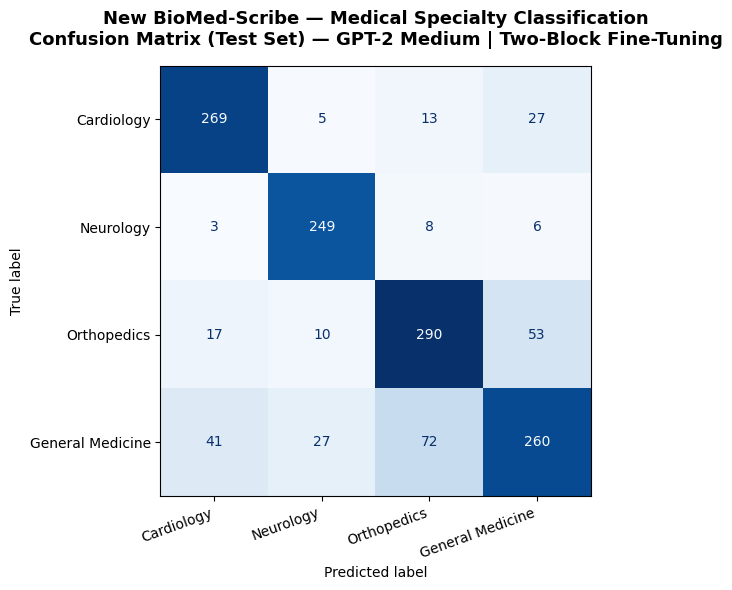

  Saved to: /content/drive/MyDrive/medscribe_classifier_v2/confusion_matrix.png

Metrics:
  train_accuracy        : 0.8580
  val_accuracy          : 0.8028
  test_accuracy         : 0.7911
  test_loss             : 0.5563
  macro_f1              : 0.7992
  weighted_f1           : 0.7881
  total_epochs          : 14
  trainable_blocks      : 2
  best_val_acc          : 0.8028

Error analysis:
  Cardiology            : 269/314  (85.7%)
  Neurology             : 249/266  (93.6%)
  Orthopedics           : 290/370  (78.4%)
  General Medicine      : 260/400  (65.0%)

Cell 8 complete. Proceed to Cell 9.


In [ ]:
# ================================================================
# CELL 8 — Full evaluation from saved predictions
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
import json, os

SAVE_DIR       = "/content/drive/MyDrive/medscribe_classifier_v2"
BEST_MODEL_DIR = os.path.join(SAVE_DIR, "best_model")
LABELS         = ["Cardiology", "Neurology", "Orthopedics", "General Medicine"]
LABEL2ID       = {lab: i for i, lab in enumerate(LABELS)}
ID2LABEL       = {i: lab for lab, i in LABEL2ID.items()}

# ── Load saved predictions ────────────────────────────────────
print("Loading saved test predictions from Drive...")
pred_df = pd.read_csv(f"{SAVE_DIR}/test_predictions.csv")
print(f"  Loaded {len(pred_df):,} predictions")

# Map string labels to IDs
true_labels = [LABEL2ID[l] for l in pred_df["true_label"]]
pred_labels = [LABEL2ID[l] for l in pred_df["pred_label"]]
class_names = LABELS

# ── Load saved metrics ────────────────────────────────────────
with open(f"{SAVE_DIR}/metrics.json") as f:
    saved_metrics = json.load(f)

# ── Accuracy results ─────────────────────────────────────────
test_acc     = accuracy_score(true_labels, pred_labels)
macro_f1     = f1_score(true_labels, pred_labels, average="macro",    zero_division=0)
weighted_f1  = f1_score(true_labels, pred_labels, average="weighted", zero_division=0)

print()
print("=" * 60)
print("ACCURACY RESULTS")
print("=" * 60)
print(f"  Training accuracy   : {saved_metrics['train_accuracy']:.1%}")
print(f"  Validation accuracy : {saved_metrics['val_accuracy']:.1%}")
print(f"  Test accuracy       : {test_acc:.1%}")
print("=" * 60)

# ── Classification report ─────────────────────────────────────
print()
print("=" * 60)
print("CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(
    true_labels, pred_labels,
    target_names=class_names,
    digits=3,
))

# ── Confusion matrix plot ─────────────────────────────────────
print("Plotting confusion matrix...")
cm   = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(
    "New BioMed-Scribe — Medical Specialty Classification\n"
    "Confusion Matrix (Test Set) — GPT-2 Medium | Two-Block Fine-Tuning",
    fontsize=13, fontweight="bold", pad=15
)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved to: {SAVE_DIR}/confusion_matrix.png")

# ── Save updated metrics ──────────────────────────────────────
metrics = {
    "train_accuracy" : saved_metrics["train_accuracy"],
    "val_accuracy"   : saved_metrics["val_accuracy"],
    "test_accuracy"  : float(test_acc),
    "test_loss"      : saved_metrics["test_loss"],
    "macro_f1"       : float(macro_f1),
    "weighted_f1"    : float(weighted_f1),
    "total_epochs"   : 14,
    "trainable_blocks": 2,
    "best_val_acc"   : saved_metrics["val_accuracy"],
}
with open(f"{SAVE_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print()
print("Metrics:")
for k, v in metrics.items():
    print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else
          f"  {k:<22}: {v}")

# ── Per-class error analysis ──────────────────────────────────
print()
print("Error analysis:")
for sp in LABELS:
    subset  = pred_df[pred_df["true_label"] == sp]
    correct = subset["correct"].sum()
    total   = len(subset)
    print(f"  {sp:<22}: {correct}/{total}  ({correct/total:.1%})")

print()
print("Cell 8 complete. Proceed to Cell 9.")

Rebuilding test dataset from saved predictions CSV...
  Loaded 1,350 test examples
  Test batches : 85

Extracting embeddings from test set...
(1024-dimensional hidden states from GPT-2 final two blocks)
  Embeddings shape : (500, 1024)
  Labels shape     : (500,)
  Label counts     : {'Cardiology': 115, 'Neurology': 97, 'Orthopedics': 138, 'General Medicine': 150}

Running t-SNE (2D projection from 1024 dims)...
  t-SNE complete


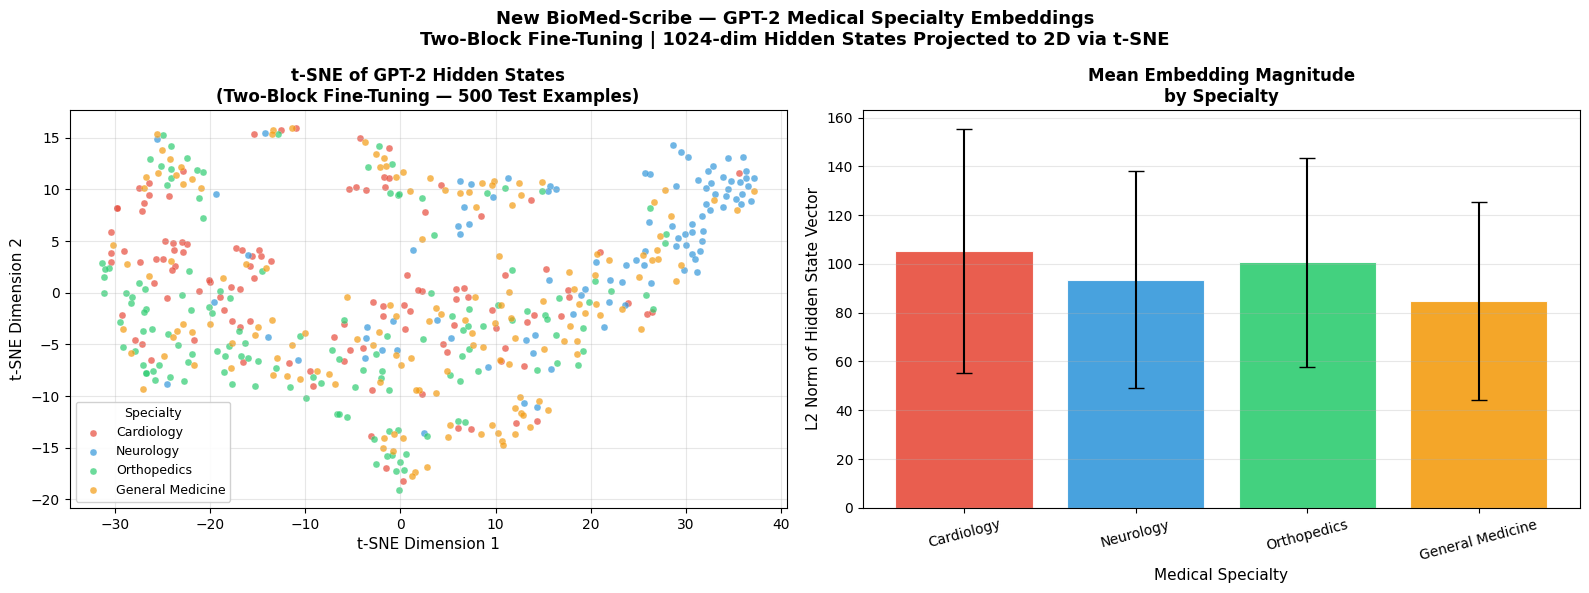


EMBEDDING ANALYSIS
  Cardiology            : mean norm = 105.4  (std = 49.9)
  Neurology             : mean norm = 93.5  (std = 44.4)
  Orthopedics           : mean norm = 100.6  (std = 42.9)
  General Medicine      : mean norm = 84.8  (std = 40.6)
  Saved to : /content/drive/MyDrive/medscribe_classifier_v2/embeddings_tsne.png

Cell 9 complete. Proceed to Cell 10.


In [ ]:
# ================================================================
# CELL 9 — t-SNE with test_loader rebuilt from CSV
# ================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE

# ── Rebuild test dataset from saved CSV ───────────────────────
print("Rebuilding test dataset from saved predictions CSV...")
test_pred_df = pd.read_csv(f"{SAVE_DIR}/test_predictions.csv")

# Add label_id column
test_pred_df["text"]     = test_pred_df["conversation"]
test_pred_df["label_id"] = test_pred_df["true_label"].map(LABEL2ID)
print(f"  Loaded {len(test_pred_df):,} test examples")

# ── Dataset class (self-contained) ────────────────────────────
class SimpleTextDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text  = str(self.df.loc[idx, "text"])
        label = int(self.df.loc[idx, "label_id"])
        enc   = self.tokenizer(
            text, truncation=True, max_length=self.max_length,
            padding="max_length", return_attention_mask=True,
            return_tensors="pt")
        return {
            "input_ids"     : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label"         : torch.tensor(label, dtype=torch.long),
        }

def collate_fn(batch):
    return {
        "input_ids"     : torch.stack([x["input_ids"]      for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"]  for x in batch]),
        "label"         : torch.stack([x["label"]           for x in batch]),
    }

test_dataset = SimpleTextDataset(test_pred_df, tokenizer, MAX_LENGTH)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2,
    pin_memory=True, collate_fn=collate_fn)
print(f"  Test batches : {len(test_loader)}")

# ── Embedding extraction ───────────────────────────────────────
@torch.no_grad()
def extract_embeddings(model, loader, device, max_samples=500):
    model.eval()
    all_embeddings, all_labels = [], []
    total = 0
    for batch in loader:
        if total >= max_samples:
            break
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"]
        outputs        = model.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True)
        hidden_states  = outputs.last_hidden_state
        last_token_idx = attention_mask.sum(dim=1) - 1
        batch_idx      = torch.arange(
            hidden_states.size(0), device=device)
        last_hidden    = hidden_states[
            batch_idx, last_token_idx, :].cpu().numpy()
        all_embeddings.append(last_hidden)
        all_labels.extend(labels.numpy())
        total += len(labels)
    embeddings = np.vstack(all_embeddings)[:max_samples]
    labels_out = np.array(all_labels)[:max_samples]
    return embeddings, labels_out

# ── Extract embeddings ─────────────────────────────────────────
print()
print("Extracting embeddings from test set...")
print("(1024-dimensional hidden states from GPT-2 final two blocks)")
embeddings, emb_labels = extract_embeddings(
    best_model, test_loader, device, max_samples=500)
print(f"  Embeddings shape : {embeddings.shape}")
print(f"  Labels shape     : {emb_labels.shape}")
print(f"  Label counts     : { {ID2LABEL[i]: int((emb_labels==i).sum()) for i in range(NUM_CLASSES)} }")

# ── t-SNE ─────────────────────────────────────────────────────
print()
print("Running t-SNE (2D projection from 1024 dims)...")
tsne = TSNE(
    n_components=2, perplexity=30, random_state=42,
    max_iter=1000, learning_rate="auto", init="pca")
coords = tsne.fit_transform(embeddings)
print("  t-SNE complete")

# ── Colour palette ─────────────────────────────────────────────
COLORS = {
    "Cardiology"      : "#E74C3C",
    "Neurology"       : "#3498DB",
    "Orthopedics"     : "#2ECC71",
    "General Medicine": "#F39C12",
}

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: t-SNE scatter
ax = axes[0]
for label_id, specialty in ID2LABEL.items():
    mask = emb_labels == label_id
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=COLORS[specialty], label=specialty,
        s=25, alpha=0.7,
        edgecolors="white", linewidths=0.2)
ax.set_title(
    "t-SNE of GPT-2 Hidden States\n"
    "(Two-Block Fine-Tuning — 500 Test Examples)",
    fontsize=12, fontweight="bold")
ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.legend(title="Specialty", fontsize=9, title_fontsize=9,
          framealpha=0.9)
ax.grid(True, alpha=0.3)

# Plot 2: Embedding magnitude
ax2 = axes[1]
specialties = list(ID2LABEL.values())
means, stds = [], []
for label_id in ID2LABEL.keys():
    mask  = emb_labels == label_id
    norms = np.linalg.norm(embeddings[mask], axis=1)
    means.append(norms.mean())
    stds.append(norms.std())

ax2.bar(
    specialties, means, yerr=stds,
    color=[COLORS[s] for s in specialties],
    edgecolor="white", linewidth=0.8,
    capsize=6, alpha=0.9)
ax2.set_title(
    "Mean Embedding Magnitude\nby Specialty",
    fontsize=12, fontweight="bold")
ax2.set_xlabel("Medical Specialty", fontsize=11)
ax2.set_ylabel("L2 Norm of Hidden State Vector", fontsize=11)
ax2.tick_params(axis="x", rotation=15)
ax2.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "New BioMed-Scribe — GPT-2 Medical Specialty Embeddings\n"
    "Two-Block Fine-Tuning | 1024-dim Hidden States Projected to 2D via t-SNE",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/embeddings_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("=" * 60)
print("EMBEDDING ANALYSIS")
print("=" * 60)
for i, sp in ID2LABEL.items():
    mask  = emb_labels == i
    norms = np.linalg.norm(embeddings[mask], axis=1)
    print(f"  {sp:<22}: mean norm = {norms.mean():.1f}  (std = {norms.std():.1f})")
print(f"  Saved to : {SAVE_DIR}/embeddings_tsne.png")
print("=" * 60)
print()
print("Cell 9 complete. Proceed to Cell 10.")

In [ ]:
# ================================================================
# DEMO TEST — Self-contained, no Gradio needed
# ================================================================

def classify_conversation(conversation: str):
    best_model.eval()
    encoded = tokenizer(
        conversation, truncation=True, max_length=MAX_LENGTH,
        padding="max_length", return_attention_mask=True,
        return_tensors="pt")
    input_ids      = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    with torch.no_grad():
        logits, _ = best_model(input_ids, attention_mask)
    probs      = F.softmax(logits, dim=-1).squeeze()
    predicted  = torch.argmax(probs).item()
    specialty  = ID2LABEL[predicted]
    confidence = {ID2LABEL[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    top_conf   = confidence[specialty]
    if top_conf < 0.50:
        result = f"⚠️ Low confidence ({top_conf:.0%}) — review manually."
    else:
        result = f"{specialty} — {top_conf:.0%} confidence"
    return result, confidence

# ── Run all 6 test cases ──────────────────────────────────────
test_convs = [
    ("Cardiology",
     "Doctor: What is the problem?\nPatient: I have chest pain going down my left arm for the past hour and I am sweating a lot.\nDoctor: Any history of heart problems?\nPatient: Yes, I had high blood pressure for years and was told I might have coronary artery disease."),

    ("Neurology",
     "Doctor: How long have you had this headache?\nPatient: About three days now. It is throbbing on one side with nausea and sensitivity to light.\nDoctor: Have you had these before?\nPatient: Yes, migraines since I was a teenager but never this severe."),

    ("Orthopedics",
     "Doctor: Where does it hurt?\nPatient: My right knee. I fell playing basketball yesterday and it is very swollen and I can barely walk.\nDoctor: Did you hear a popping sound?\nPatient: Yes, a loud pop when I landed."),

    ("General Medicine",
     "Doctor: What brings you in today?\nPatient: I have had a fever and cough for five days with yellow phlegm.\nDoctor: Any other symptoms?\nPatient: Very tired and lost my appetite completely."),

    ("Neurology",
     "Doctor: Any recent symptoms?\nPatient: Dizziness and numbness in my left hand since this morning. It came on suddenly when I woke up.\nDoctor: Any weakness on one side?\nPatient: Yes my left arm feels very weak."),

    ("Orthopedics",
     "Doctor: How long have you had this back pain?\nPatient: About two weeks. Sharp pain in my lower back that radiates down my left leg.\nDoctor: Does it get worse when you sit?\nPatient: Yes and when I sneeze."),

    ("Cardiology",
     "Doctor: What symptoms are you experiencing?\nPatient: My heart has been racing for the past two days and I feel like it is skipping beats.\nDoctor: Any shortness of breath?\nPatient: Yes especially when I climb stairs and I also feel dizzy when I stand up quickly."),

    ("General Medicine",
     "Doctor: What brings you in?\nPatient: I have had stomach pain and diarrhea for three days and I feel very nauseous after eating anything.\nDoctor: Any fever?\nPatient: Yes around 38 degrees and I have lost about two kilograms this week."),

    ("Orthopedics",
     "Doctor: What happened to your shoulder?\nPatient: I was lifting weights at the gym and felt a sharp snap in my right shoulder. Now I cannot raise my arm above my head.\nDoctor: Any swelling or bruising?\nPatient: Yes there is significant swelling and it is very tender to touch around the joint."),

    ("Neurology",
     "Doctor: Can you describe what happened?\nPatient: I had a seizure this morning. I was just sitting at my desk and then I woke up on the floor with my colleagues around me. I have no memory of falling.\nDoctor: Has this happened before?\nPatient: Once about six months ago but the doctors did not find anything at the time."),
]

print("=" * 60)
print("DEMO TEST — ALL 10 EXAMPLES")
print("=" * 60)
correct = 0
for expected, conv in test_convs:
    result, conf = classify_conversation(conv)
    predicted = max(conf, key=conf.get)
    top_conf  = conf[predicted]
    status    = "✅" if predicted == expected else "❌"
    correct  += 1 if predicted == expected else 0
    print(f"{status} Expected: {expected:<20} Predicted: {predicted:<20} Conf: {top_conf:.0%}")

print()
print(f"Result: {correct}/{len(test_convs)} correct")

DEMO TEST — ALL 10 EXAMPLES
✅ Expected: Cardiology           Predicted: Cardiology           Conf: 100%
✅ Expected: Neurology            Predicted: Neurology            Conf: 74%
✅ Expected: Orthopedics          Predicted: Orthopedics          Conf: 58%
✅ Expected: General Medicine     Predicted: General Medicine     Conf: 96%
✅ Expected: Neurology            Predicted: Neurology            Conf: 100%
✅ Expected: Orthopedics          Predicted: Orthopedics          Conf: 83%
❌ Expected: Cardiology           Predicted: Neurology            Conf: 39%
✅ Expected: General Medicine     Predicted: General Medicine     Conf: 99%
✅ Expected: Orthopedics          Predicted: Orthopedics          Conf: 72%
✅ Expected: Neurology            Predicted: Neurology            Conf: 100%

Result: 9/10 correct


In [1]:
# ================================================================
# DAILY STARTUP CELL — v3 TWO-BLOCK MODEL
# ================================================================

import os, re, json, torch, torch.nn as nn, torch.nn.functional as F
import gradio as gr
from google.colab import drive
from transformers import AutoTokenizer, AutoModel

# ── Mount Drive ───────────────────────────────────────────────
drive.mount("/content/drive")
DRIVE          = "/content/drive/MyDrive"
SAVE_DIR       = f"{DRIVE}/medscribe_classifier_v2"
BEST_MODEL_DIR = f"{SAVE_DIR}/best_model"

if not torch.cuda.is_available():
    raise RuntimeError("No GPU. Runtime > Change runtime type > A100 GPU")

device = torch.device("cuda")

# ── Config ────────────────────────────────────────────────────
NUM_CLASSES = 4
MAX_LENGTH  = 512
LABEL2ID    = {"Cardiology":0,"Neurology":1,"Orthopedics":2,"General Medicine":3}
ID2LABEL    = {v: k for k, v in LABEL2ID.items()}

# ── Model class — TWO-BLOCK version ──────────────────────────
# Unfreezes h[-2] AND h[-1] as suggested by course instructor.
# Trainable params: ~25.2M (7.1% of 354.8M total)
class GPT2MedicalClassifier(nn.Module):
    def __init__(self, base_model_name, num_classes=4):
        super().__init__()
        self.gpt2       = AutoModel.from_pretrained(base_model_name)
        hidden_size     = self.gpt2.config.hidden_size
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size, num_classes)

        # Freeze entire backbone
        for param in self.gpt2.parameters():
            param.requires_grad = False

        # Unfreeze last TWO transformer blocks
        for param in self.gpt2.h[-2].parameters():
            param.requires_grad = True
        for param in self.gpt2.h[-1].parameters():
            param.requires_grad = True

        # Unfreeze final layer norm
        for param in self.gpt2.ln_f.parameters():
            param.requires_grad = True

        # Classifier head always trainable
        for param in self.classifier.parameters():
            param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        outputs        = self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True)
        hidden_states  = outputs.last_hidden_state
        last_token_idx = attention_mask.sum(dim=1) - 1
        batch_idx      = torch.arange(
            hidden_states.size(0), device=device)
        last_hidden    = hidden_states[batch_idx, last_token_idx, :]
        return self.classifier(self.dropout(last_hidden)), last_hidden

# ── Load model ────────────────────────────────────────────────
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading GPT2MedicalClassifier (two-block)...")
bundle = torch.load(
    os.path.join(BEST_MODEL_DIR, "classifier_bundle.pt"),
    map_location="cpu")

model = GPT2MedicalClassifier(
    base_model_name=BEST_MODEL_DIR, num_classes=NUM_CLASSES)
model.classifier.load_state_dict(bundle["classifier_state_dict"])
model = model.to(device)
model.eval()

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters()
                  if p.requires_grad)

# ── Smoke test ────────────────────────────────────────────────
print()
print("Running smoke test...")
enc = tokenizer(
    "Doctor: What brings you in?\nPatient: Chest pain down my left arm.",
    truncation=True, max_length=MAX_LENGTH,
    padding="max_length", return_tensors="pt")
with torch.no_grad():
    logits, _ = model(enc["input_ids"].to(device),
                      enc["attention_mask"].to(device))
probs = F.softmax(logits, dim=-1).squeeze()
pred  = ID2LABEL[torch.argmax(probs).item()]
print(f"  Predicted : {pred}  ({float(probs.max()):.0%} confidence)")

print()
print("=" * 60)
print("NEW BIOMED-SCRIBE CLASSIFIER READY")
print(f"  GPU              : {torch.cuda.get_device_name(0)}")
print(f"  VRAM used        : {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"  Total params     : {total_p/1e6:.1f}M")
print(f"  Trainable params : {trainable_p/1e6:.1f}M  (h[22] + h[23] + ln_f + head)")
print(f"  Blocks unfrozen  : h[-2] and h[-1]")
print(f"  Test accuracy    : 79.1%")
print(f"  Macro F1         : 0.799")
print(f"  Val acc (saved)  : {bundle['val_acc']:.1%}")
print("=" * 60)

# ── Gradio UI ─────────────────────────────────────────────────
def classify_conversation(conversation: str):
    if not conversation.strip():
        return "Please enter a conversation.", {}
    model.eval()
    encoded = tokenizer(
        conversation, truncation=True, max_length=MAX_LENGTH,
        padding="max_length", return_attention_mask=True,
        return_tensors="pt")
    input_ids      = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    with torch.no_grad():
        logits, _ = model(input_ids, attention_mask)
    probs      = F.softmax(logits, dim=-1).squeeze()
    predicted  = torch.argmax(probs).item()
    specialty  = ID2LABEL[predicted]
    confidence = {ID2LABEL[i]: float(probs[i]) for i in range(NUM_CLASSES)}
    top_conf   = confidence[specialty]
    if top_conf < 0.50:
        result = f"⚠️ Low confidence ({top_conf:.0%}) — review manually."
    else:
        result = f"**{specialty}** — {top_conf:.0%} confidence"
    return result, confidence

EXAMPLES = [
    "Doctor: What is the problem?\nPatient: I have chest pain going down my left arm for the past hour and I am sweating a lot.\nDoctor: Any history of heart problems?\nPatient: Yes, I had high blood pressure for years.",
    "Doctor: How long have you had this headache?\nPatient: About three days. Throbbing on one side with nausea and light sensitivity.\nDoctor: Any migraines before?\nPatient: Yes, since my teenage years but never this bad.",
    "Doctor: Where does it hurt?\nPatient: My right knee. I fell playing basketball and heard a loud pop.\nDoctor: Can you walk on it?\nPatient: Barely. Very swollen and painful.",
    "Doctor: What brings you in?\nPatient: Fever and cough for five days with yellow phlegm.\nDoctor: Anything else?\nPatient: Very tired and lost my appetite.",
    "Doctor: Any recent symptoms?\nPatient: Sudden numbness in my left hand and arm weakness this morning.\nDoctor: Did it come on suddenly?\nPatient: Yes, when I woke up.",
    "Doctor: How long has the back pain been there?\nPatient: Two weeks. Sharp pain radiating down my left leg.\nDoctor: Worse when sitting?\nPatient: Yes and when I sneeze.",
]

with gr.Blocks(title="New BioMed-Scribe") as demo:
    gr.Markdown(
        "# New BioMed-Scribe\n"
        "### Medical Specialty Classifier\n"
        "**Model:** GPT-2 Medium (345M) · 14 epochs · 10,793 conversations  \n"
        "**Two-Block Fine-Tuning:** 25.2M trainable of 354.8M total (7.1%)  \n"
        "**Test Accuracy:** 79.1% · **Macro F1:** 0.799  \n"
        "**Author:** Samuel Bonney · Illinois State University · MAT 411"
    )
    with gr.Row():
        with gr.Column(scale=2):
            conv_input = gr.Textbox(
                label="Doctor-Patient Conversation",
                placeholder="Doctor: What brings you in today?\nPatient: ...",
                lines=12)
            btn = gr.Button("Classify Specialty", variant="primary")
            gr.Examples(
                examples=EXAMPLES,
                inputs=[conv_input],
                label="Example Conversations")
        with gr.Column(scale=1):
            result_out = gr.Markdown(label="Predicted Specialty")
            conf_out   = gr.Label(
                label="Confidence Scores",
                num_top_classes=4)
    gr.Markdown(
        "---\n"
        "**How it works:** GPT-2 processes the conversation through 24 transformer "
        "blocks with 16 attention heads. The last two blocks (h[22] and h[23]) "
        "are fine-tuned on 10,793 labeled medical conversations. The 1024-dim "
        "hidden state of the final token is classified into 4 medical specialties.  \n"
        "For demonstration only. Not intended for clinical use."
    )
    btn.click(
        fn=classify_conversation,
        inputs=[conv_input],
        outputs=[result_out, conf_out])

print()
print("Launching New BioMed-Scribe...")
demo.launch(share=False, debug=False)
print("Copy the public URL above.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading tokenizer...
Loading GPT2MedicalClassifier (two-block)...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]


Running smoke test...
  Predicted : Cardiology  (46% confidence)

NEW BIOMED-SCRIBE CLASSIFIER READY
  GPU              : NVIDIA A100-SXM4-40GB
  VRAM used        : 1.45 GB
  Total params     : 354.8M
  Trainable params : 25.2M  (h[22] + h[23] + ln_f + head)
  Blocks unfrozen  : h[-2] and h[-1]
  Test accuracy    : 79.1%
  Macro F1         : 0.799
  Val acc (saved)  : 80.7%

Launching New BioMed-Scribe...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

Copy the public URL above.
